# Ch.00 — Overview: HFT taxonomy

Filimonov, *High-Frequency Trading* (Perm Winter School 2013).  
Slice: **ETH** on **Hyperliquid + Deribit + Kraken**, artifacts in `out/ch00_overview/`.  
Lib: `research.lib.hftpat` (framing only here). Kill: co-lo / Hibernia vanity.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/filmonov')
OUT = BOOK / 'out' / 'ch00_overview'
FIGS = OUT / 'figs'
cov = json.loads((OUT / 'coverage.json').read_text())
tax = json.loads((OUT / 'taxonomy.json').read_text())
print('symbol', cov.get('symbol'), 'days', cov.get('days'))
print('n_complete', cov['summary']['n_complete'], '/', cov['summary']['n_venue_days'],
      'n_tob', cov['summary']['n_tob'])
rows = pd.DataFrame([
    {'venue': r['venue'], 'day': r['day'],
     'complete': r['completeness']['complete'],
     'coverage': r['completeness']['coverage'],
     'n': r['n_trades'], 'tob_ok': r['tob_ok'],
     'tob_source': r.get('tob_source')}
    for r in cov['rows']
])
print(rows.pivot_table(index='venue', columns='day', values='coverage').round(3))
print('SEC attrs:', len(tax['sec_attrs']), '| strategies:', len(tax['strategy_map']))



symbol ETH days ['2026-09-26', '2026-09-27', '2026-09-30']
n_complete 9 / 9 n_tob 9
day          2026-09-26  2026-09-27  2026-09-30
venue                                          
deribit           0.998       0.501       0.821
hyperliquid       0.991       0.490       0.819
kraken            0.864       0.501       0.708
SEC attrs: 5 | strategies: 7


## Day-completeness coverage



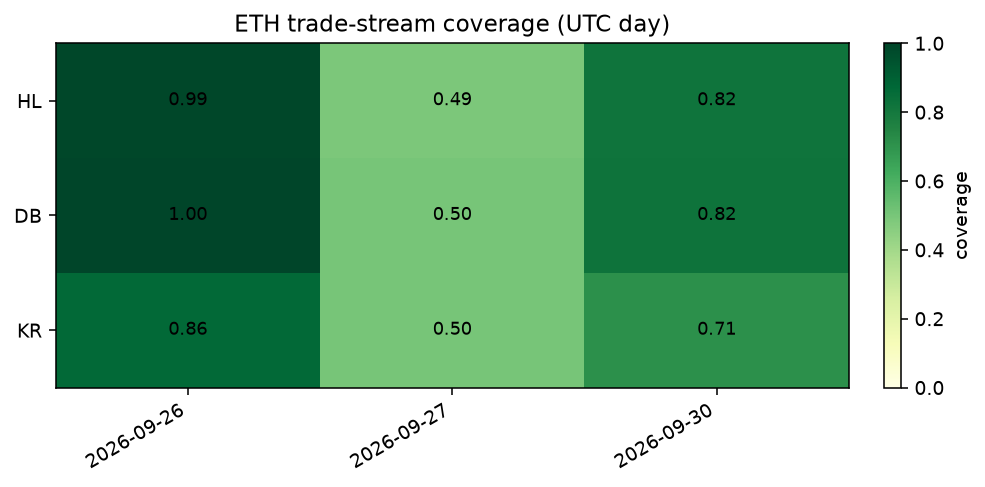

In [2]:
display(Image(filename=str(FIGS / 'fig_coverage.png')))



## Taxonomy tile (deck strategy map → packages)



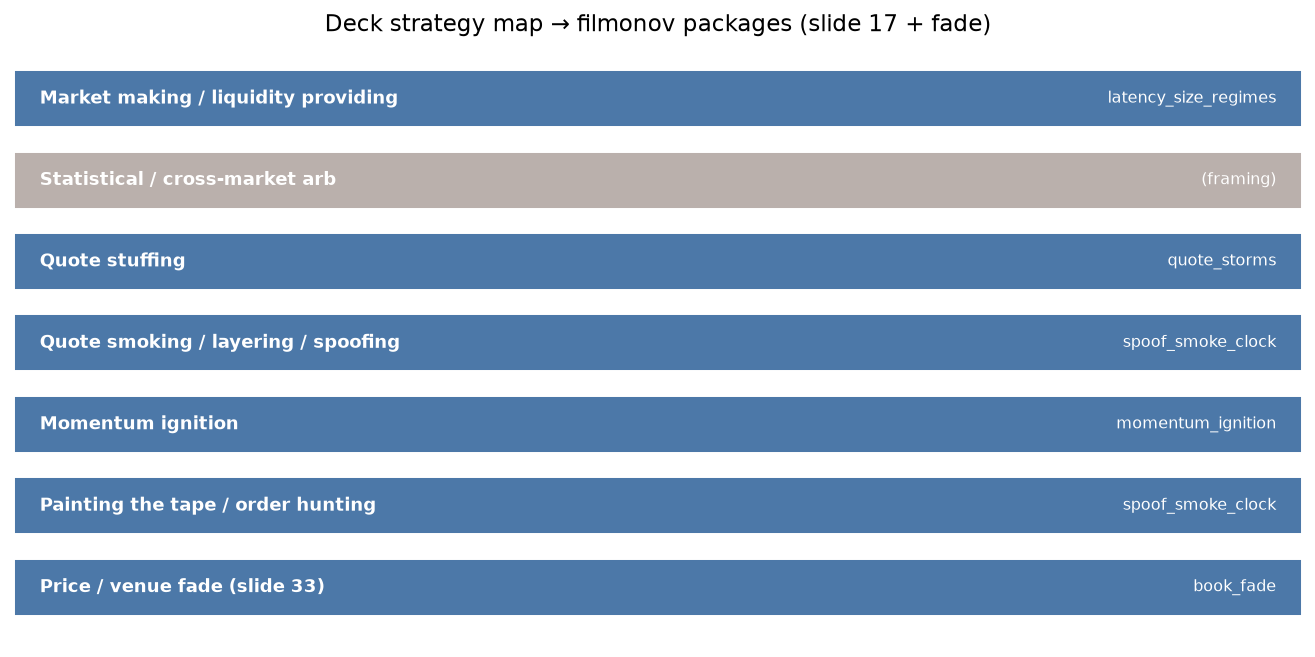

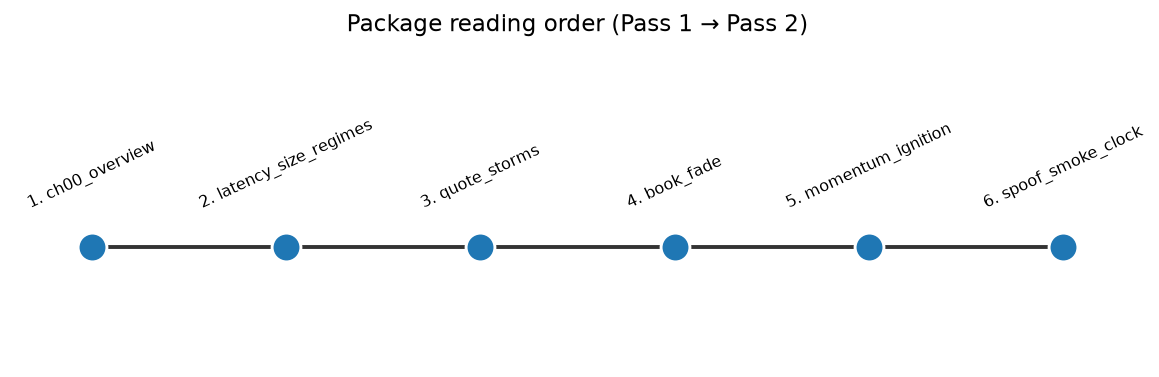

In [3]:
display(Image(filename=str(FIGS / 'fig_taxonomy.png')))
display(Image(filename=str(FIGS / 'fig_reading_order.png')))



## Sibling reuse (do not re-Promote crash/vstat/lob)



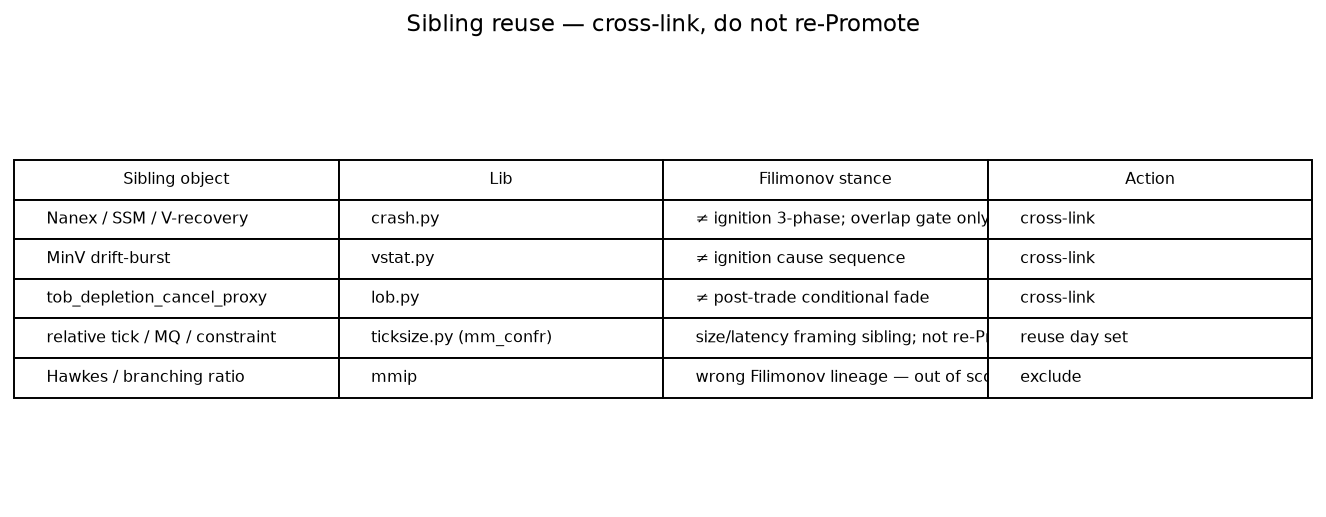

,object,lib,filmonov,action
0,Nanex / SSM / V-recovery,crash.py,≠ ignition 3-phase; overlap gate only,cross-link
1,MinV drift-burst,vstat.py,≠ ignition cause sequence,cross-link
2,tob_depletion_cancel_proxy,lob.py,≠ post-trade conditional fade,cross-link
3,relative tick / MQ / constraint,ticksize.py (mm_confr),size/latency framing sibling; not re-Promote,reuse day set
4,Hawkes / branching ratio,mmip,wrong Filimonov lineage — out of scope,exclude


In [4]:
display(Image(filename=str(FIGS / 'fig_sibling_reuse.png')))
sib = json.loads((OUT / 'sibling_reuse.json').read_text())
display(pd.DataFrame(sib))



## Candidates (Pass 1 draft)

- `disc.hft_taxonomy_tile` — **Hold** (Promote only if labels add beyond crash/mmip/lob)
- `id.colo_hibernia_vanity` — **Kill**
- `id.fx_triangle_fee_free` — **Kill**

